<a href="https://colab.research.google.com/github/vamsiram89/-Projects/blob/main/Amazon_web_scraping_iphone_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup Environment in Google Colab

In [15]:
!pip install requests beautifulsoup4 pandas


Import Required Libraries

In [16]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import time



#extracting each product details


In [17]:
# Function to extract Product Title
def get_title(soup):

    try:
        # Outer Tag Object
        title = soup.find("span", attrs={"id":'productTitle'})

        # Inner NavigatableString Object
        title_value = title.text

        # Title as a string value
        title_string = title_value.strip()

    except AttributeError:
        title_string = ""

    return title_string

# Function to extract Product Price
def get_price(soup):
    try:
        # Look for the price in 'a-offscreen' within an 'a-price' container (most common structure)
        price_span = soup.find("span", attrs={'class':'a-price'})
        if price_span:
            price = price_span.find("span", attrs={'class':'a-offscreen'})
            if price:
                return price.get_text(strip=True)

        # Fallback to older IDs if the above fails
        try:
            price = soup.find("span", attrs={'id':'priceblock_ourprice'})
            if price: return price.get_text(strip=True)
        except:
            pass

        try:
            price = soup.find("span", attrs={'id':'priceblock_dealprice'})
            if price: return price.get_text(strip=True)
        except:
            pass

        return ""
    except Exception:
        return ""

# Function to extract Product Rating
def get_rating(soup):
    try:
        # Most reliable way to get the full rating text
        rating_span = soup.find("span", attrs={'class':'a-icon-alt'})
        if rating_span:
            return rating_span.get_text(strip=True)
        else:
            return ""
    except Exception:
        return ""

# Function to extract Number of User Reviews
def get_review_count(soup):
    try:
        review_count = soup.find("span", attrs={'id':'acrCustomerReviewText'})
        if review_count: return review_count.get_text(strip=True)
        else: return ""

    except AttributeError:
        review_count = ""

    return review_count

# Function to extract Availability Status
def get_availability(soup):
    try:
        available = soup.find("div", attrs={'id':'availability'})
        if available:
            available_span = available.find("span")
            if available_span: return available_span.get_text(strip=True)
        return "Not Available"

    except AttributeError:
        available = "Not Available"

    return available

In [23]:
if __name__ == '__main__':

    # add your user agent
    HEADERS = ({'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36', 'Accept-Language': 'en-IN,en;q=0.9'})

    # The webpage URL (using the URL from the kernel state, which is amazon.in for iphone)
    URL = "https://www.amazon.in/s?k=iphone"

    # HTTP Request
    webpage = requests.get(URL, headers=HEADERS)

    # Soup Object containing all data
    soup = BeautifulSoup(webpage.content, "html.parser")

    # Fetch links as List of Tag Objects
    # This part might need adjustment if Amazon changes their search result link classes
    links = soup.find_all("a", attrs={'class':'a-link-normal s-no-outline'}) # or 's-pagination-item' or 'a-link-normal'

    # Store the links
    links_list = []

    # Loop for extracting links from Tag Objects
    for link in links:
            # Ensure to get the href attribute
            href = link.get('href')
            if href and not href.startswith('#'): # Avoid internal anchors
                links_list.append(href)

    d = {"title":[], "price":[], "rating":[], "reviews":[],"availability":[]}

    # Loop for extracting product details from each link
    for link_path in links_list:
        # Construct full URL for product page, handling both relative and absolute paths
        if link_path.startswith("http"):
            full_product_url = link_path
        else:
            full_product_url = "https://www.amazon.in" + link_path

        new_webpage = requests.get(full_product_url, headers=HEADERS)

        new_soup = BeautifulSoup(new_webpage.content, "html.parser")

        # Function calls to display all necessary product information
        d['title'].append(get_title(new_soup))
        d['price'].append(get_price(new_soup))
        d['rating'].append(get_rating(new_soup))
        d['reviews'].append(get_review_count(new_soup))
        d['availability'].append(get_availability(new_soup))


    amazon_df = pd.DataFrame.from_dict(d)
    # amazon_df['title'].replace('', np.nan, inplace=True)
    amazon_df = amazon_df.dropna(subset=['title'])
    amazon_df.to_csv("amazon_iphones_data.csv", header=True, index=False)

In [19]:
amazon_df

,title,price,rating,reviews,availability
0,"iPhone Air 256 GB: Thinnest iPhone Ever, 16.63...","₹99,000.00",4.2 out of 5 stars,(116),In stock
1,iPhone 17 Pro Max 2 TB: 17.42 cm (6.9″) Displa...,"₹2,29,900.00",4.5 out of 5 stars,(221),In stock
2,iPhone 17 Pro 1 TB: 15.93 cm (6.3″) Display wi...,"₹1,74,900.00",4.5 out of 5 stars,(313),In stock
3,iPhone 16e 128 GB: Built for Apple Intelligenc...,"₹52,390.00",4.5 out of 5 stars,"(1,083)",In stock
4,"iPhone Air 512 GB: Thinnest iPhone Ever, 16.63...","₹1,13,990.00",4.2 out of 5 stars,(116),In stock
5,Samsung Galaxy S25 FE 5G Smartphone with Galax...,"₹69,299.00",4.0 out of 5 stars,(43),In stock
6,"Oppo Reno15 5G (Twilight Blue, 12GB RAM, 256GB...","₹48,999.00",4.4 out of 5 stars,(101),In stock
7,"realme NARZO 90 5G (Victory Gold,8GB+128GB) | ...","₹18,499.00",4.2 out of 5 stars,(312),In stock
8,OnePlus 13s | Snapdragon® 8 Elite | Smarter wi...,"₹55,999.00",4.5 out of 5 stars,"(1,815)",In stock
9,"Google Pixel 9A (Porcelain, 256 GB) (8 GB RAM)","₹40,999.00",4.3 out of 5 stars,(204),Only 1 left in stock.


In [20]:
import matplotlib.pyplot as plt

## Visualization 1: Bar Chart for Ratings

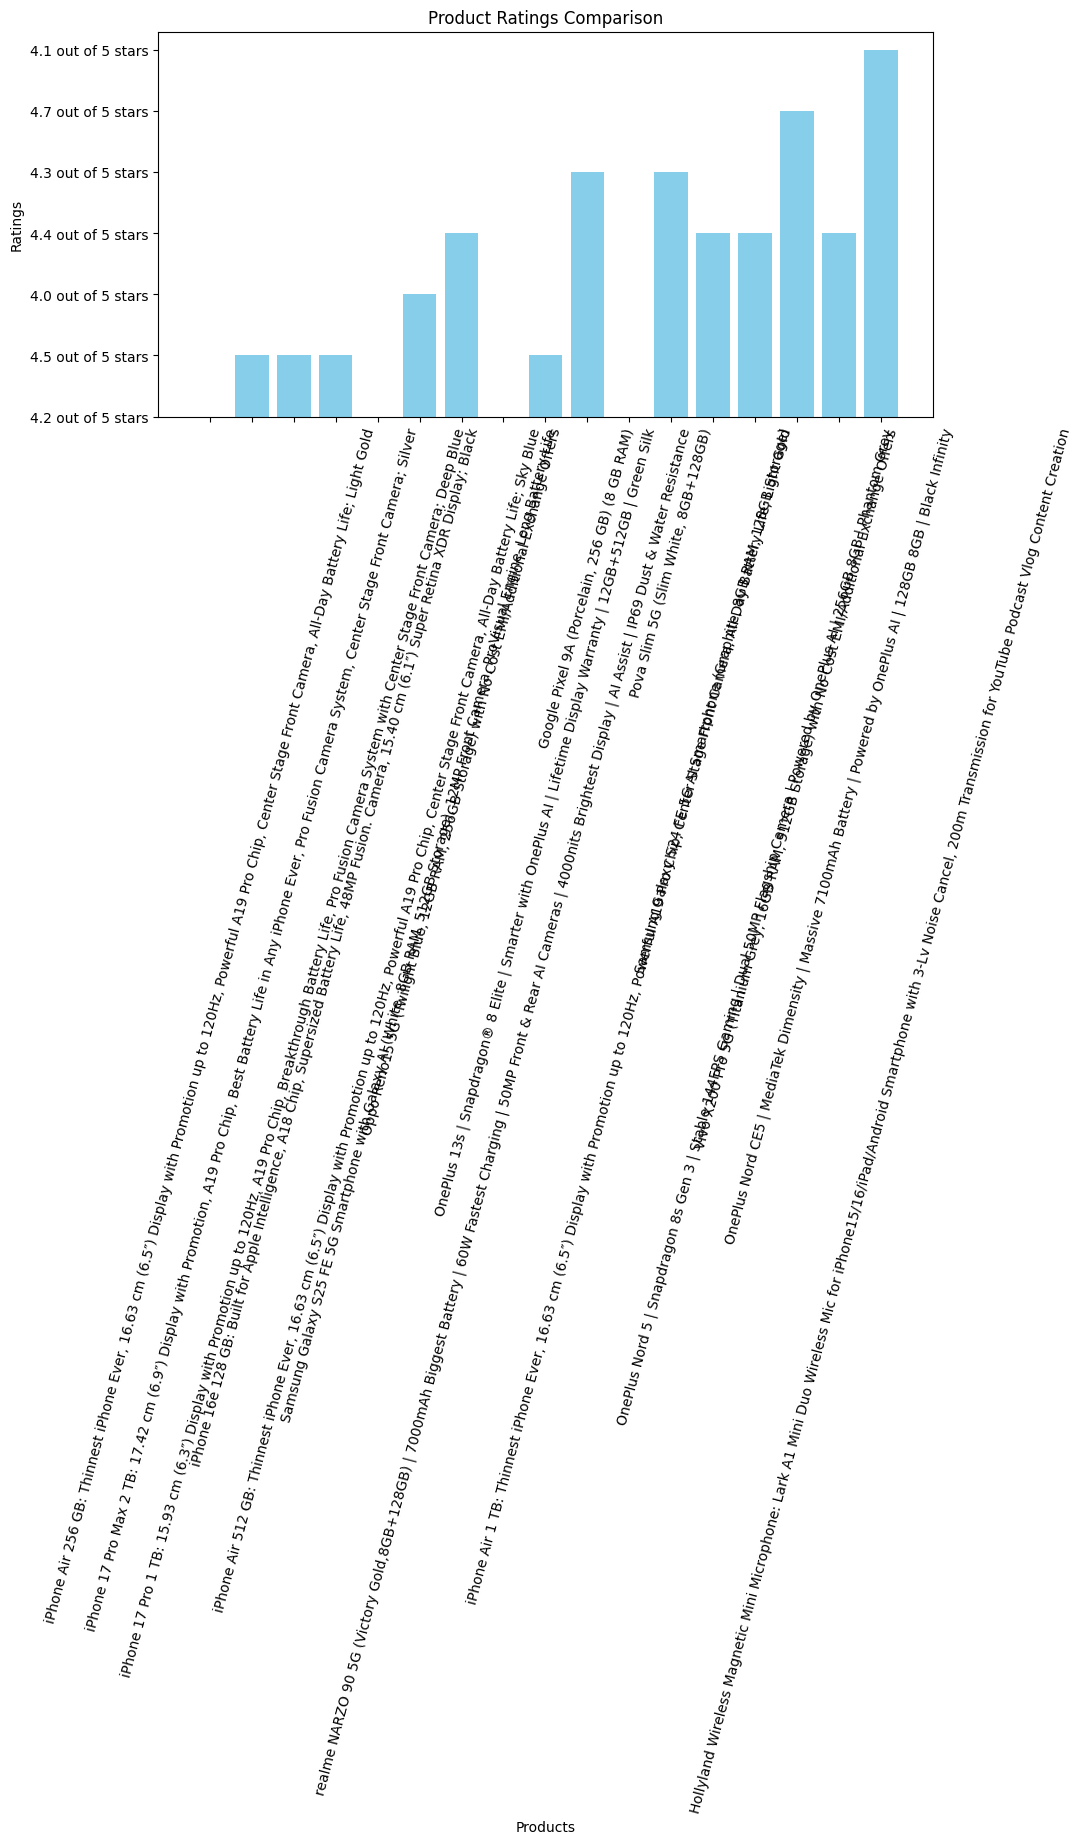

In [21]:
# 🔹 Visualization 1: Bar Chart for Ratings
plt.figure(figsize=(10, 5))
plt.bar(amazon_df["title"],amazon_df["rating"], color="skyblue")
plt.xlabel("Products")
plt.ylabel("Ratings")
plt.title("Product Ratings Comparison")
plt.xticks(rotation=75)
plt.show()

In [22]:
import plotly.express as px

fig2 = px.pie(amazon_df,
              names="availability",
              title="Product Availability",
              color="availability",
              hover_data=["title"],  # 👈 This adds product names on hover
              color_discrete_map={"In Stock": "green",
                                  "Not Available": "red",
                                  "Only 5 left in stock - order soon.": "orange",
                                  "Only 15 left in stock - order soon.": "blue"})

fig2.update_traces(hoverinfo="label+percent+text", textinfo="percent", text=amazon_df["title"])  # 👈 Customizing hover

fig2.show()
